# Lab 1 — Projectile Motion Solver
* **Name:** [Alex Bebb] abebb@vols.utk.edu
* **Date:** [8/30/2026]

In [18]:
import math
import numpy as np
import matplotlib.pyplot as plt
print("Engine is running!")

Engine is running!


---
## Part A — One-Dimensional Free Fall

In [19]:
def simulate_freefall(h, dt, g=9.81):
    """Simulate 1-D free fall using the Euler Method.

    Parameters:
        h  : initial height (m)
        dt : time step (s)
        g  : gravitational acceleration (m/s²)

    Returns: 
        t_arr, y_arr, vy_arr : lists of time, height, velocity
    """
    y, vy = h, 0.0
    t = 0.0

    t_arr, y_arr, vy_arr = [t], [y], [vy]

    while y >= 0:
        #Compute acceleration
        ay = -g #Since gravity is pulling downward in our 1-D sim

        #Euler update
        y  = y + vy * dt  #New position = old position + (velocity * time step)
        vy = vy + ay * dt #New velocity = old velocity + (acceleration * time step)
        t  = t + dt

        t_arr.append(t)
        y_arr.append(y)
        vy_arr.append(vy)

    return t_arr, y_arr, vy_arr

In [20]:
# Call the function with h=100 and dt=0.1, and save the results
t_data, y_data, v_data = simulate_freefall(h=100.0, dt=0.1)

# Check the results by printing out the final time step
print("Time of flight:", t_data[-1], "seconds")
print("Number of data points calculated:", len(t_data))

Time of flight: 4.6 seconds
Number of data points calculated: 47


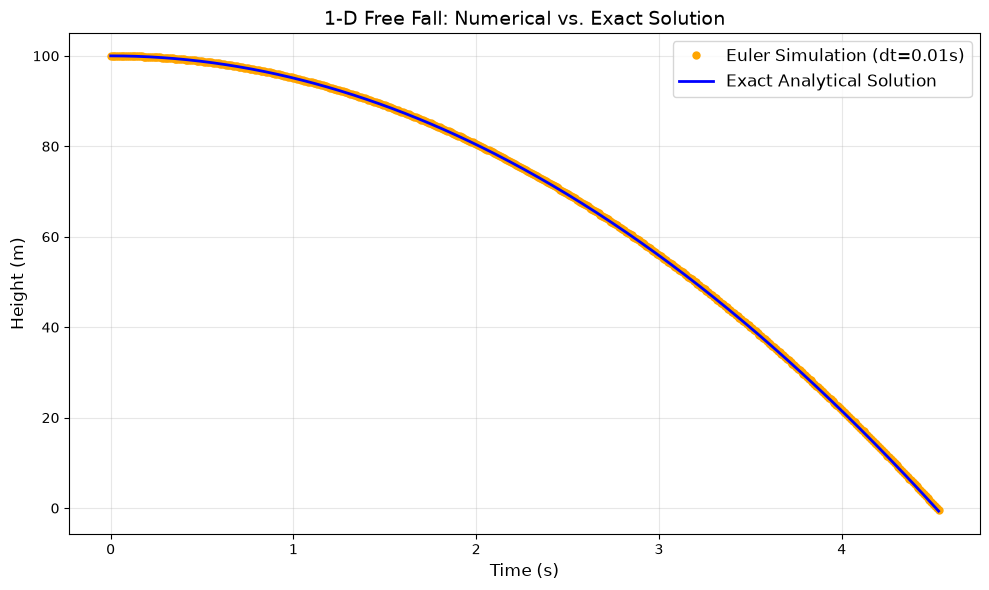

             SIMULATION COMPARISON             
Simulation Final Time:     4.5300 seconds
Exact Final Time:          4.5152 seconds
Time Percent Error:        0.33%
--------------------------------------------------
Simulation Final Velocity: -44.4393 m/s
Exact Final Velocity:      -44.2945 m/s
Velocity Percent Error:    -0.33%


In [21]:
# 1. Change dt here to 1.0, 0.1, or 0.01 to answer Question 2
dt_value = 0.01
h = 100.0
g = 9.81
t_data, y_data, v_data = simulate_freefall(h=h, dt=dt_value)

# Calculate exact values
y_exact = [h - 0.5 * g * t**2 for t in t_data]
exact_final_time = math.sqrt((2 * h) / g)
exact_final_velocity = -g * exact_final_time

# Calculate percent errors using abs()
time_error = abs(t_data[-1] - exact_final_time) / exact_final_time * 100
vel_error = abs(v_data[-1] - exact_final_velocity) / exact_final_velocity * 100

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(t_data, y_data, 'o', label=f'Euler Simulation (dt={dt_value}s)', color='orange', markersize=5)
plt.plot(t_data, y_exact, 'b-', label='Exact Analytical Solution', linewidth=2)

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Height (m)', fontsize=12)
plt.title('1-D Free Fall: Numerical vs. Exact Solution', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the Comparison table
print("="*50)
print("             SIMULATION COMPARISON             ")
print("="*50)
print(f"Simulation Final Time:     {t_data[-1]:.4f} seconds")
print(f"Exact Final Time:          {exact_final_time:.4f} seconds")
print(f"Time Percent Error:        {time_error:.2f}%")
print("-"*50)
print(f"Simulation Final Velocity: {v_data[-1]:.4f} m/s")
print(f"Exact Final Velocity:      {exact_final_velocity:.4f} m/s")
print(f"Velocity Percent Error:    {vel_error:.2f}%")
print("="*50)


### Notebook questions
***What is the numerical landing time? What is the exact landing time? What is the percentage error?***

The Numerical landing time is 4.6000 seconds, while the Exact landing time is 4.5152 seconds, which gives a percent error of 1.88%.*

The Numerical final velocity is -45.1260 m/s, while the Exact Final Velocity is -44.2945 m/s, which gives a percent error of -1.88%.*


***Try `dt = 1.0`, `dt = 0.1`, and `dt = 0.01`. How does the error change? (One sentence is fine.)***

When `dt=1.0` the time error is 32.88% and the velocity error is -32.88%.

When `dt=0.1` the time error is 1.88% and the velocity error is -1.88%.

When `dt=0.01` the time error is 0.33% and the velocity error is -0.33%.

As the time step, dt, gets smaller, the smaller the percentage errors become. This not only means it is more accurate but it is (slowly) approaching the limit going to infinity.

---
## Part B — Two-Dimensional Projectile Motion

In [22]:
def simulate_projectile_2d(v0, theta_deg, dt, g=9.81):
    """Simulate 2-D projectile motion using the Euler Method."""
    theta_rad = np.radians(theta_deg)
    vx = v0 * np.cos(theta_rad)
    vy = v0 * np.sin(theta_rad)

    x = 0.0
    y = 0.0
    t = 0.0

    # Added vx_arr and vy_arr to store velocity history
    t_arr, x_arr, y_arr = [t], [x], [y]
    vx_arr, vy_arr = [vx], [vy]

    while y >= 0:
        ax = 0.0          
        ay = -g           

        # Euler updates
        x  = x + vx * dt  
        y  = y + vy * dt  
        vx = vx + ax * dt 
        vy = vy + ay * dt 
        t  = t + dt

        # Append the velocities at each step
        t_arr.append(t)
        x_arr.append(x)
        y_arr.append(y)
        vx_arr.append(vx)
        vy_arr.append(vy)

    # Return all 5 lists
    return t_arr, x_arr, y_arr, vx_arr, vy_arr



In [23]:
# Defining parameters
v0_test = 30.0
theta_test = 45.0
dt_test = 0.01

#  Calling the 2D function
t_2d, x_2d, y_2d, vx_2d, vy_2d = simulate_projectile_2d(v0=v0_test, theta_deg=theta_test, dt=dt_test)


# Printing out a quick check to see how it ran
print("Simulation complete!")
print(f"Total time in air: {t_2d[-1]:.2f} seconds")
print(f"Total horizontal distance (Range): {x_2d[-1]:.2f} meters")


Simulation complete!
Total time in air: 4.34 seconds
Total horizontal distance (Range): 92.07 meters


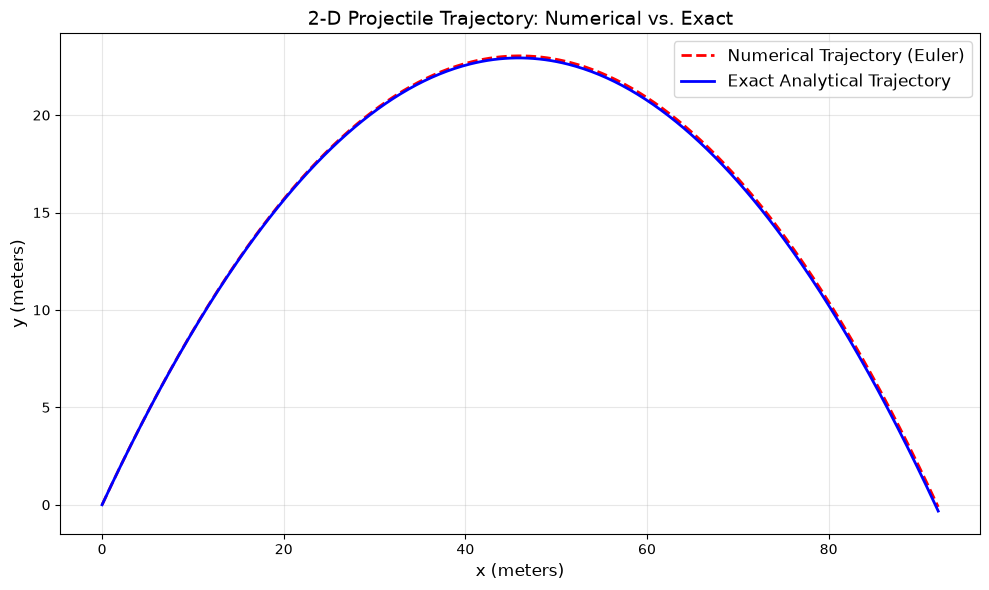

             MAXIMUM HEIGHT ERROR ANALYSIS             
Simulation Maximum Height: 23.0419 meters
Exact Maximum Height:      22.9358 meters
--> Max Height % Error:    0.4628%


In [24]:
# Redefine physics parameters for exact equations
g = 9.81
v0 = 30.0
theta_rad = np.radians(45.0)

# Calculate the exact analytical y-values matching every x-position in the simulation
y_exact_trajectory = [x * np.tan(theta_rad) - (g / (2 * v0**2 * np.cos(theta_rad)**2)) * x**2 for x in x_2d]

# find the simulated max height, then calculate theoretical max height
sim_max_height = max(y_2d)
exact_max_height = (v0**2 * np.sin(theta_rad)**2) / (2 * g)
height_error = abs(sim_max_height - exact_max_height) / exact_max_height * 100

# Create the Trajectory Plot
plt.figure(figsize=(10, 6))
plt.plot(x_2d, y_2d, 'r--', label='Numerical Trajectory (Euler)', linewidth=2)
plt.plot(x_2d, y_exact_trajectory, 'b-', label='Exact Analytical Trajectory', linewidth=2)

plt.xlabel('x (meters)', fontsize=12)
plt.ylabel('y (meters)', fontsize=12)
plt.title('2-D Projectile Trajectory: Numerical vs. Exact', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the Maximum Height Error analysis
print("="*50)
print("             MAXIMUM HEIGHT ERROR ANALYSIS             ")
print("="*50)
print(f"Simulation Maximum Height: {sim_max_height:.4f} meters")
print(f"Exact Maximum Height:      {exact_max_height:.4f} meters")
print(f"--> Max Height % Error:    {height_error:.4f}%")
print("="*50)


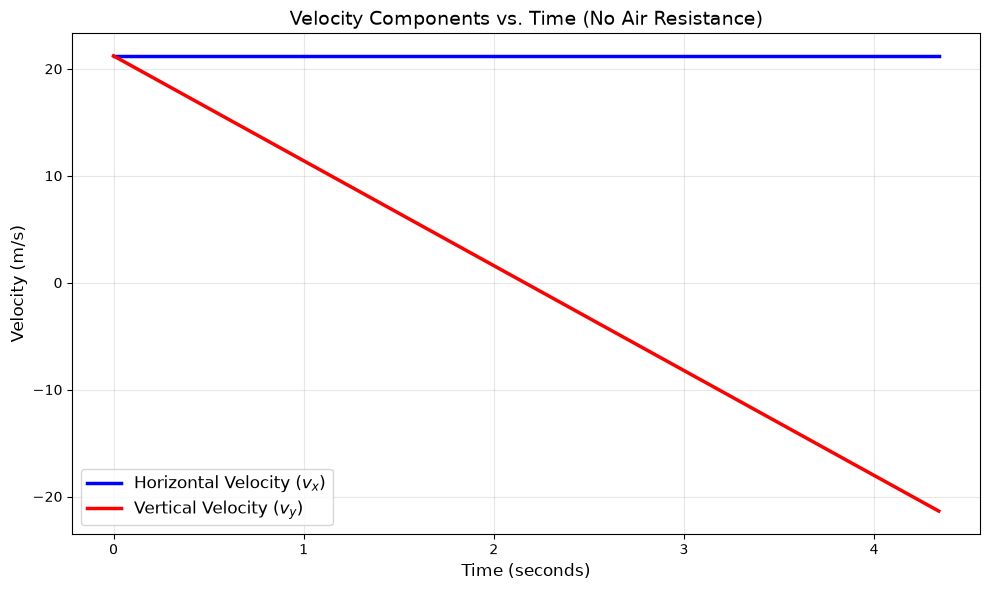

In [25]:
plt.figure(figsize=(10, 6))

# Plot horizontal velocity component (vx) over time
plt.plot(t_2d, vx_2d, 'b-', label='Horizontal Velocity ($v_x$)', linewidth=2.5)

# Plot vertical velocity component (vy) over time
plt.plot(t_2d, vy_2d, 'r-', label='Vertical Velocity ($v_y$)', linewidth=2.5)

# Label the axes and add titles
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Velocity (m/s)', fontsize=12)
plt.title('Velocity Components vs. Time (No Air Resistance)', fontsize=14)

# Add a legend and clean up layout
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Horizontal Velocity ($v_{x}$): 
This line is completely flat (constant). Because we are ignoring air resistance, there are no physical forces acting horizontally on the projectile ($a_x = 0$). Therefore, it maintains its exact initial horizontal launch speed throughout the entire flight.

#### Vertical Velocity ($v_y$): 
This line is a straight downward slope (linear). Gravity exerts a constant downward acceleration ($a_y = -g$), causing the vertical speed to decrease linearly, pass through zero at the absolute peak of the trajectory, and continue accelerating downward until it hits the ground.

             PART B: 2-D SIMULATION ACCURACY            
Flight Time | Sim: 4.3400s | Exact: 4.3248s | Error: 0.35%
Max Range   | Sim: 92.0653m | Exact: 91.7431m | Error: 0.35%
Max Height  | Sim: 23.0419m | Exact: 22.9358m | Error: 0.46%



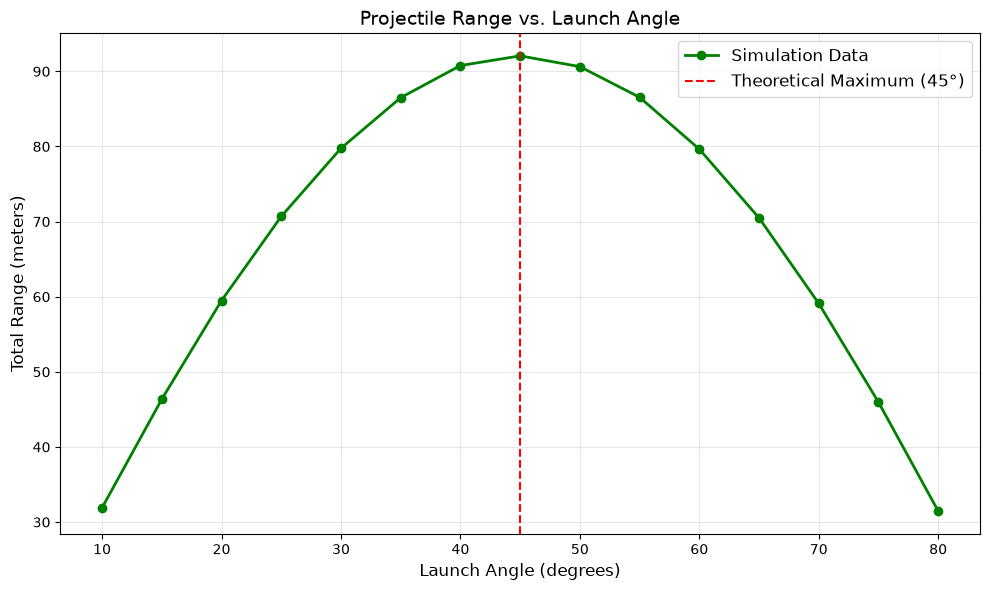

The simulation found the maximum range was 92.07 meters at an angle of 45°.


In [26]:
# Exact analytical formulas for 2D projectile motion on flat ground
exact_flight_time = (2 * v0_test * np.sin(theta_rad)) / g
exact_range = (v0_test**2 * np.sin(2 * theta_rad)) / g
exact_max_height = (v0_test**2 * np.sin(theta_rad)**2) / (2 * g)

# Calculate simulated values from our arrays
sim_flight_time = t_2d[-1]
sim_range = x_2d[-1]
sim_max_height = max(y_2d)

# Calculate absolute percentage errors
time_err_2d = abs(sim_flight_time - exact_flight_time) / exact_flight_time * 100
range_err_2d = abs(sim_range - exact_range) / exact_range * 100
height_err_2d = abs(sim_max_height - exact_max_height) / exact_max_height * 100

print("="*60)
print("             PART B: 2-D SIMULATION ACCURACY            ")
print("="*60)
print(f"Flight Time | Sim: {sim_flight_time:.4f}s | Exact: {exact_flight_time:.4f}s | Error: {time_err_2d:.2f}%")
print(f"Max Range   | Sim: {sim_range:.4f}m | Exact: {exact_range:.4f}m | Error: {range_err_2d:.2f}%")
print(f"Max Height  | Sim: {sim_max_height:.4f}m | Exact: {exact_max_height:.4f}m | Error: {height_err_2d:.2f}%")
print("="*60 + "\n")


# Create arrays to hold experiment data
angles = np.arange(10, 81, 5) # Generates 10, 15, 20, ..., 80
simulated_ranges = []

# Loop through each angle and run a fresh simulation
for angle in angles:
    # Run simulation with current loop angle
    t_sweep, x_sweep, y_sweep, _, _ = simulate_projectile_2d(v0=v0_test, theta_deg=angle, dt=dt_test)
    
    # Store the final horizontal distance reached
    simulated_ranges.append(x_sweep[-1])

# Plot Range vs. Angle
plt.figure(figsize=(10, 6))
plt.plot(angles, simulated_ranges, 'go-', label='Simulation Data', linewidth=2, markersize=6)

# From the "Nice Plots" appendix/hint
plt.xlabel('Launch Angle (degrees)', fontsize=12)
plt.ylabel('Total Range (meters)', fontsize=12)
plt.title('Projectile Range vs. Launch Angle', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axvline(x=45, color='red', linestyle='--', label='Theoretical Maximum (45°)')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Find the maximum range from data and its matching angle
max_sim_range = max(simulated_ranges)
best_angle = angles[simulated_ranges.index(max_sim_range)]

print(f"The simulation found the maximum range was {max_sim_range:.2f} meters at an angle of {best_angle}°.")


### Step 6 Observations & Analysis

* **At what angle is the range maximized?**  
  The simulation shows that the horizontal range reaches its absolute peak value at an angle of exactly **$45^\circ$**.

* **Does this match the theory?**  
  Yes, this matches standard analytical kinematic theory perfectly. The theoretical range equation for a projectile launched on flat ground is:
  
  $$R = \frac{v_0^2 \sin(2\theta)}{g}$$
  
  The maximum possible mathematical value for a sine function is $1$, which occurs when its inner argument equals $90^\circ$. Setting $2\theta = 90^\circ$ and solving for our launch angle gives us our optimal physical trajectory angle:
  
  $$\theta = 45^\circ$$

Therefore, our numerical Euler method simulation matches the exact laws of classical mechanics.


### Notebook Questions

#### a. Why is $v_x$ constant and $v_y$ linear? Connect this to the forces acting on the projectile.
According to Newton's Second Law ($\vec{F} = m\vec{a}$), an object can only accelerate if there is a net force acting on it. 
* **Horizontal Axis ($x$):** Because we assume zero air resistance in Part B, there are absolutely no physical forces acting sideways ($\vec{F}_x = 0$). Since there is no force, horizontal acceleration is zero ($a_x = 0$), meaning the horizontal velocity ($v_x$) must remain completely constant.
* **Vertical Axis ($y$):** The force of gravity pulls straight down with a constant force ($\vec{F}_y = -mg$). This creates a uniform downward acceleration ($a_y = -g$). Since acceleration is the derivative (slope) of velocity, a constant acceleration forces the vertical velocity ($v_y$) to decrease linearly over time.

#### b. Does the angle for maximum range agree with theory? Should it, given your assumptions?
Yes, our simulation found that the maximum range occurs at exactly $45^\circ$, which perfectly matches the theoretical prediction derived from classical kinematics. It *should* agree perfectly in this specific part of the lab because our model's assumptions (a completely flat ground, a uniform gravitational field, and a total absence of atmospheric drag) are identical to the ideal boundary conditions used to derive the calculus-based range formula ($R = \frac{v_0^2\sin(2\theta)}{g}$).


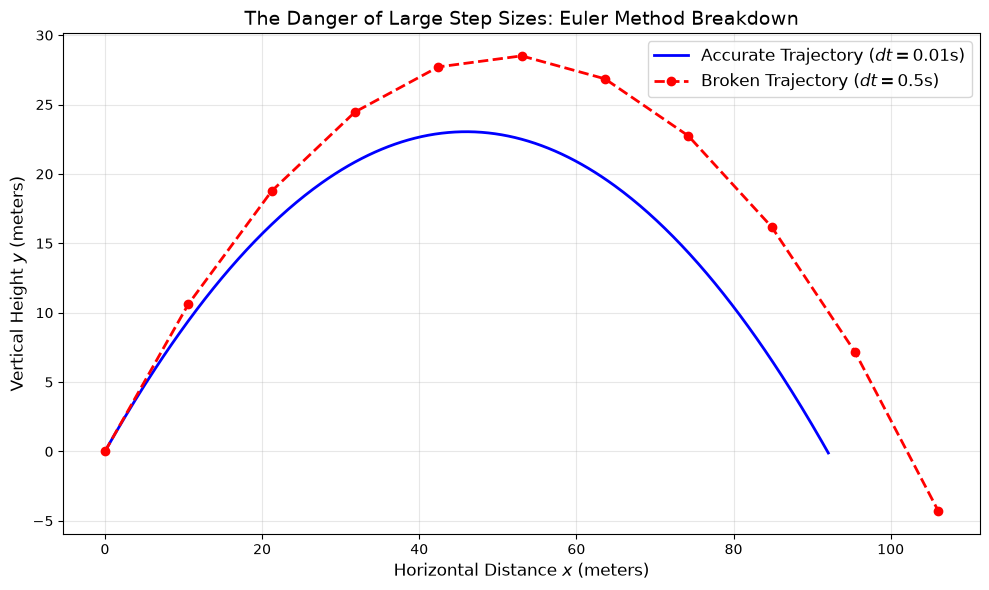

Accurate Range (dt=0.01s): 92.07 meters
Broken Range (dt=0.50s):   106.07 meters
Absolute Distance Error:   14.00 meters


In [27]:
# Use the baseline 2D parameters from Part B (v0=30, theta=45, g=9.81)
v0_b = 30.0
theta_b = 45.0
g_b = 9.81

# Run clean simulation with a tiny step size (dt = 0.01)
t_clean, x_clean, y_clean, _, _ = simulate_projectile_2d(v0_b, theta_b, dt=0.01, g=g_b)

# Run the broken simulation with a massive step size (dt = 0.5)
t_broken, x_broken, y_broken, _, _ = simulate_projectile_2d(v0_b, theta_b, dt=0.5, g=g_b)

# Plot them side by side to show the error
plt.figure(figsize=(10, 6))
plt.plot(x_clean, y_clean, 'b-', label='Accurate Trajectory ($dt = 0.01$s)', linewidth=2)
plt.plot(x_broken, y_broken, 'ro--', label='Broken Trajectory ($dt = 0.5$s)', linewidth=2, markersize=6)

plt.xlabel('Horizontal Distance $x$ (meters)', fontsize=12)
plt.ylabel('Vertical Height $y$ (meters)', fontsize=12)
plt.title('The Danger of Large Step Sizes: Euler Method Breakdown', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Accurate Range (dt=0.01s): {x_clean[-1]:.2f} meters")
print(f"Broken Range (dt=0.50s):   {x_broken[-1]:.2f} meters")
print(f"Absolute Distance Error:   {abs(x_clean[-1] - x_broken[-1]):.2f} meters")


#### c. What happens if you increase $dt$ to 0.5? Explain what goes wrong.
When we increase $dt$ to $0.5$ seconds, the simulation completely breaks down, overshooting the true trajectory and introducing an immense landing range error of exactly **14.00 meters** ($106.07\text{ m}$ vs. $92.07\text{ m}$). 

The fundamental failure here is that the basic Euler method assumes velocity and acceleration stay completely static over the entire duration of a time step. When $dt$ is small ($0.01\text{s}$), this snapshot approximation is fine. But when $dt$ is a massive $0.5\text{s}$, the projectile calculates its downward gravity drop using an old vertical speed from half a second ago. It delays tracking its true curvature, overestimates its height, misses the true landing impact threshold, and drifts wildly away from physical reality.


---
## Part C - Projectile with Air Resistance

In [28]:
def simulate_projectile_drag(v0, theta_deg, dt, g, b_over_m):
    """Simulate 2-D projectile motion with quadratic drag using the Euler Method.

    Parameters:
        v0        : initial launch speed (m/s)
        theta_deg : launch angle in degrees
        dt        : time step (s)
        g         : gravitational acceleration (m/s²)
        b_over_m  : drag coefficient divided by mass (m⁻¹)

    Returns: 
        t_arr, x_arr, y_arr, vx_arr, vy_arr : lists of data arrays
    """
    # Convert angle and split components (via Hint 1)
    theta_rad = np.radians(theta_deg)
    vx = v0 * np.cos(theta_rad)
    vy = v0 * np.sin(theta_rad)

    # Initialize positions and time
    x = 0.0
    y = 0.0
    t = 0.0

    # Set up tracking arrays for positions and velocities
    t_arr, x_arr, y_arr = [t], [x], [y]
    vx_arr, vy_arr = [vx], [vy]

    # The Simulation Loop
    while y >= 0:
        # Compute current speed and drag accelerations
        speed = np.sqrt(vx**2 + vy**2)
        ax = -(b_over_m) * speed * vx
        ay = -g - (b_over_m) * speed * vy

        x  = x + vx * dt  
        y  = y + vy * dt  
        vx = vx + ax * dt 
        vy = vy + ay * dt 
        t  = t + dt

        # Append new values to history lists
        t_arr.append(t)
        x_arr.append(x)
        y_arr.append(y)
        vx_arr.append(vx)
        vy_arr.append(vy)

    return t_arr, x_arr, y_arr, vx_arr, vy_arr


In [29]:
# Define the baseball parameters from Step 2
v0_baseball = 45.0          # m/s (~100 mph fast pitch)
theta_baseball = 40.0       # Launch angle in degrees
b_over_m_baseball = 0.0046  # Drag coefficient / mass (m⁻¹)
dt_baseball = 0.01          # Time step (s)
g_baseball = 9.81           # Gravity (m/s²)

# Call the function WITH DRAG
t_drag, x_drag, y_drag, vx_drag, vy_drag = simulate_projectile_drag(
    v0=v0_baseball, 
    theta_deg=theta_baseball, 
    dt=dt_baseball, 
    g=g_baseball, 
    b_over_m=b_over_m_baseball
)

# Call the function WITHOUT DRAG (just set b_over_m to 0.0)
t_no_drag, x_no_drag, y_no_drag, vx_no_drag, vy_no_drag = simulate_projectile_drag(
    v0=v0_baseball, 
    theta_deg=theta_baseball, 
    dt=dt_baseball, 
    g=g_baseball, 
    b_over_m=0.0
)

print("Both simulations completed successfully!")
print(f"With drag data points: {len(t_drag)}")
print(f"No drag data points: {len(t_no_drag)}")


Both simulations completed successfully!
With drag data points: 512
No drag data points: 592


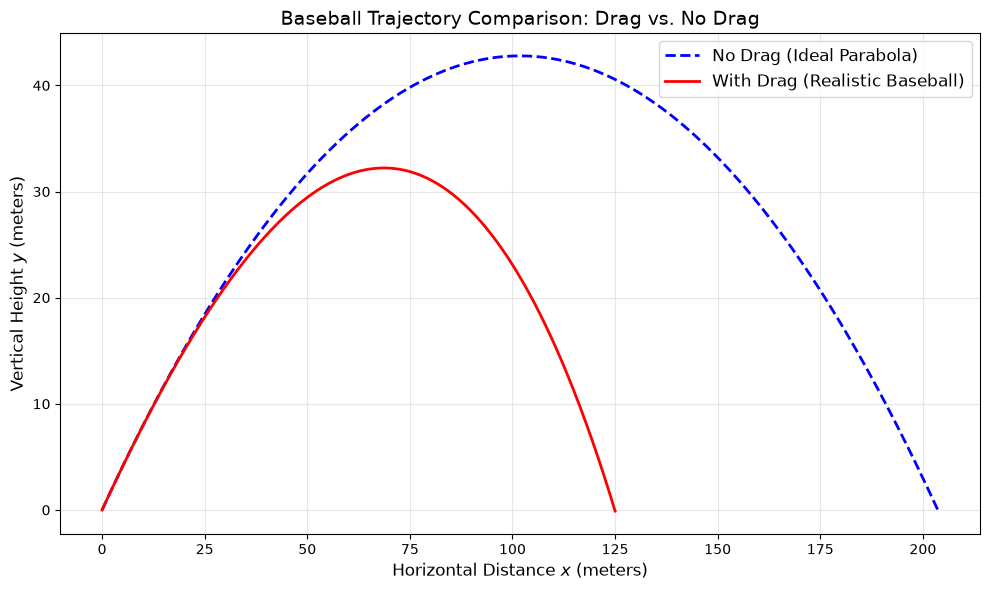

In [30]:
import matplotlib.pyplot as plt

# Create a larger figure size
plt.figure(figsize=(10, 6))

# Plot both paths (No drag as a dashed blue line, Drag as a solid red line)
plt.plot(x_no_drag, y_no_drag, 'b--', label='No Drag (Ideal Parabola)', linewidth=2)
plt.plot(x_drag, y_drag, 'r-', label='With Drag (Realistic Baseball)', linewidth=2)

# Add formal labels and titles
plt.xlabel('Horizontal Distance $x$ (meters)', fontsize=12)
plt.ylabel('Vertical Height $y$ (meters)', fontsize=12)
plt.title('Baseball Trajectory Comparison: Drag vs. No Drag', fontsize=14)

# Include a clean legend and grid background
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Display the plot
plt.show()

In [31]:
# Pull the final horizontal ranges (the last x data points before landing)
range_no_drag = x_no_drag[-1]
range_with_drag = x_drag[-1]

# Pull the maximum peak heights reached
max_height_no_drag = max(y_no_drag)
max_height_with_drag = max(y_drag)

# Calculate by what percentage drag reduces the horizontal range
# Formula: ((Ideal - Realistic) / Ideal) * 100
range_reduction_pct = ((range_no_drag - range_with_drag) / range_no_drag) * 100
height_reduction_pct = ((max_height_no_drag - max_height_with_drag) / max_height_no_drag) * 100

# Print out the structured comparison table
print("="*60)
print("             PART C: QUANTIFYING DRAG EFFECTS           ")
print("="*60)
print(f"Ideal Range (No Drag):     {range_no_drag:.2f} meters")
print(f"Realistic Range (Drag):    {range_with_drag:.2f} meters")
print(f"--> Horizontal Range Loss: {range_reduction_pct:.2f}%")
print("-"*60)
print(f"Ideal Peak Height:         {max_height_no_drag:.2f} meters")
print(f"Realistic Peak Height:     {max_height_with_drag:.2f} meters")
print(f"--> Vertical Height Loss:  {height_reduction_pct:.2f}%")
print("="*60)


             PART C: QUANTIFYING DRAG EFFECTS           
Ideal Range (No Drag):     203.73 meters
Realistic Range (Drag):    125.00 meters
--> Horizontal Range Loss: 38.64%
------------------------------------------------------------
Ideal Peak Height:         42.79 meters
Realistic Peak Height:     32.22 meters
--> Vertical Height Loss:  24.69%


**By what percentage does drag reduce the range?** 

Atmospheric air resistance reduces the horizontal range of the baseball by **$38.64\%$** (dropping from $203.73\text{ m}$ down to $125.00\text{ m}$). It also reduces the maximum peak height by **$24.69\%$**.


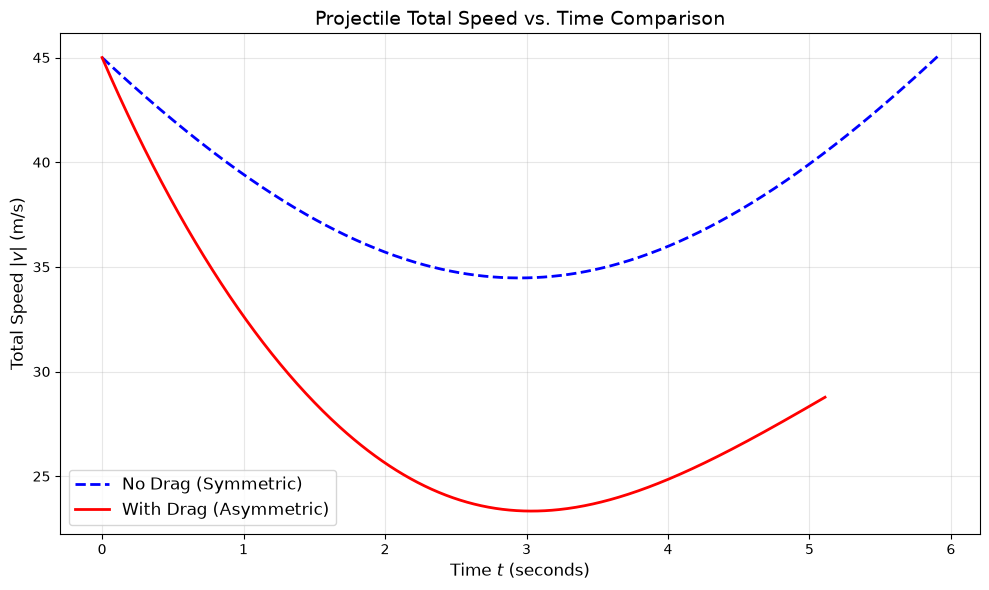

In [32]:
# Compute the total speed magnitude at each time step
speed_no_drag = np.sqrt(np.array(vx_no_drag)**2 + np.array(vy_no_drag)**2)
speed_with_drag = np.sqrt(np.array(vx_drag)**2 + np.array(vy_drag)**2)

plt.figure(figsize=(10, 6))

# Plot both speed curves over their respective time arrays
plt.plot(t_no_drag, speed_no_drag, 'b--', label='No Drag (Symmetric)', linewidth=2)
plt.plot(t_drag, speed_with_drag, 'r-', label='With Drag (Asymmetric)', linewidth=2)

# Axes labels and titles
plt.xlabel('Time $t$ (seconds)', fontsize=12)
plt.ylabel('Total Speed $|v|$ (m/s)', fontsize=12)
plt.title('Projectile Total Speed vs. Time Comparison', fontsize=14)

# Aesthetic touch-ups
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


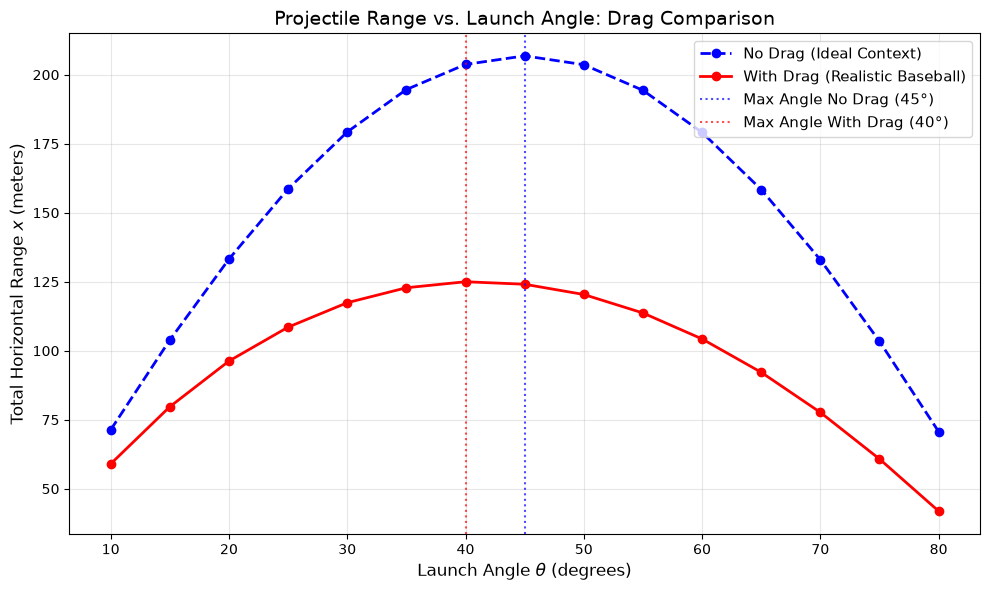

                  ANGLE SWEEP RESULTS                   
Max Range WITH DRAG occurs at a launch angle of: 40°
The absolute peak range achieved with drag is:   125.00 meters


In [33]:
# Generate an array of angles from 10 to 80 degrees (in steps of 5 degrees)
sweep_angles = np.arange(10, 81, 5)

# Empty lists to store the landing ranges for each angle experiment
ranges_no_drag_sweep = []
ranges_drag_sweep = []

# Run the experimental loop
for angle in sweep_angles:
    # Run the No Drag simulation (b_over_m = 0.0) and pull final x
    _, x_nd_sweep, _, _, _ = simulate_projectile_drag(
        v0=v0_baseball, theta_deg=angle, dt=dt_baseball, g=g_baseball, b_over_m=0.0
    )
    ranges_no_drag_sweep.append(x_nd_sweep[-1])
    
    # Run the With Drag simulation and pull final x
    _, x_d_sweep, _, _, _ = simulate_projectile_drag(
        v0=v0_baseball, theta_deg=angle, dt=dt_baseball, g=g_baseball, b_over_m=b_over_m_baseball
    )
    ranges_drag_sweep.append(x_d_sweep[-1])

# Find the absolute maximum range and matching angle for the drag case
max_drag_range = max(ranges_drag_sweep)
optimal_drag_index = ranges_drag_sweep.index(max_drag_range)
optimal_drag_angle = sweep_angles[optimal_drag_index]

# Create the dual-curve plot
plt.figure(figsize=(10, 6))
plt.plot(sweep_angles, ranges_no_drag_sweep, 'bo--', label='No Drag (Ideal Context)', linewidth=2)
plt.plot(sweep_angles, ranges_drag_sweep, 'ro-', label='With Drag (Realistic Baseball)', linewidth=2)

# Add vertical guide lines to pinpoint the peaks
plt.axvline(x=45, color='blue', linestyle=':', alpha=0.7, label='Max Angle No Drag (45°)')
plt.axvline(x=optimal_drag_angle, color='red', linestyle=':', alpha=0.7, label=f'Max Angle With Drag ({optimal_drag_angle}°)')

# Labels and styling
plt.xlabel('Launch Angle $\\theta$ (degrees)', fontsize=12)
plt.ylabel('Total Horizontal Range $x$ (meters)', fontsize=12)
plt.title('Projectile Range vs. Launch Angle: Drag Comparison', fontsize=14)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print out the final experimental findings
print("="*60)
print("                  ANGLE SWEEP RESULTS                   ")
print("="*60)
print(f"Max Range WITH DRAG occurs at a launch angle of: {optimal_drag_angle}°")
print(f"The absolute peak range achieved with drag is:   {max_drag_range:.2f} meters")
print("="*60)

**At what angle is range maximized with drag?** The maximum horizontal range with air resistance is achieved at a launch angle of **$40^\circ$** (yielding a peak distance of $125.00\text{ m}$). 

**Is it still 45°?** No, it is no longer $45^\circ$. Air resistance forces the optimal angle to shift lower because keeping a flatter, more aggressive trajectory allows the ball to pierce through the atmosphere quickly with higher horizontal speeds rather than wasting energy climbing high into the air.


### Notebook Questions

#### a. Why does drag reduce the range so dramatically?
Quadratic air resistance depends on the *square* of the object's speed ($F_{\text{drag}} \propto v^2$). Because a fastball is launched at a large initial velocity ($45\text{ m/s}$), the drag force is at its absolute maximum immediately after launch. This early deceleration strips away an immense amount of kinetic energy right at the start of the flight. As a result, the projectile's trajectory loses its classic symmetric parabolic shape; it experiences a blunt horizontal braking effect on the way up, peaking much closer to the launch point, and follows a highly compressed, steep "tailing-off" descent on the way down.

#### b. Why is the optimal launch angle with drag less than 45°?
An ideal projectile achieves maximum range at $45^\circ$ because it balances the vertical flight time with horizontal velocity perfectly. However, when air resistance is introduced, spending too much time high in the air is a massive disadvantage. A high launch angle forces the ball to spend more time traveling along an elongated, slower path where drag continuously strips its energy over a longer duration. By dropping the launch angle slightly below $45^\circ$ (to around $40^\circ \text{--} 41^\circ$), the projectile prioritizes a higher initial horizontal velocity component. This allows the ball to penetrate through the thick atmosphere, going an extra distance before the downward pull of gravity forces a landing.

#### c. Is the Euler method a good choice for this problem? How would you check?
While the Euler method is straightforward to program, it seems an inefficient choice for high-precision, long-duration physics simulations because it suffers from global accumulation errors. Over every discrete step $\Delta t$, the Euler method calculates forces based only on conditions at the *start* of that step, meaning it inherently drifts away from the true physics curves over time. 

To check if the Euler method is holding up reliably for this problem, we can perform a numerical convergence test. We would run the exact same simulation with a significantly smaller time step (such as changing $dt = 0.01\text{s}$ down to $dt = 0.001\text{s}$ and $dt = 0.0001\text{s}$). If our calculated landing range converges and stabilizes at a single value, our current $dt$ is reasonably accurate. If the values swing a lot, the Euler method is failing due to the accumulative step drift. Sp, it is good for a simpler simulation where precision isn't so important. For more sophisticated simulations where precision is of utmost importance, it is lacking.


---
## Bonus: The Home Run Problem

In [34]:
# Define constant field boundaries
x_fence = 120.0
y_fence = 3.0

# Sweep (Initial speed fixed at 45 m/s)
angles_to_test = np.arange(10, 80.1, 0.1) # 10° to 80° in precision increments
clears_no_drag = []
clears_with_drag = []

for angle in angles_to_test:
    # Test No Drag condition
    _, x_nd, y_nd, _, _ = simulate_projectile_drag(v0=45.0, theta_deg=angle, dt=0.01, g=9.81, b_over_m=0.0)
    # Check height when projectile crosses the fence distance
    x_nd_arr = np.array(x_nd)
    if x_nd_arr[-1] >= x_fence:
        idx = np.where(x_nd_arr >= x_fence)[0][0] # First index crossing 120m
        if y_nd[idx] >= y_fence:
            clears_no_drag.append(angle)
            
    # Test With Drag condition
    _, x_d, y_d, _, _ = simulate_projectile_drag(v0=45.0, theta_deg=angle, dt=0.01, g=9.81, b_over_m=0.0046)
    x_d_arr = np.array(x_d)
    if x_d_arr[-1] >= x_fence:
        idx = np.where(x_d_arr >= x_fence)[0][0]
        if y_d[idx] >= y_fence:
            clears_with_drag.append(angle)

# Sweep (Find minimum speed required at the 40° optimal angle)
optimal_angle = 40.0
speeds_to_test = np.arange(30.0, 60.0, 0.1)
required_speed = None

for speed in speeds_to_test:
    _, x_s, y_s, _, _ = simulate_projectile_drag(v0=speed, theta_deg=optimal_angle, dt=0.01, g=9.81, b_over_m=0.0046)
    x_s_arr = np.array(x_s)
    if x_s_arr[-1] >= x_fence:
        idx = np.where(x_s_arr >= x_fence)[0][0]
        if y_s[idx] >= y_fence:
            required_speed = speed
            break

print("="*60)
print("                 BONUS CHALLENGE ANSWERS                ")
print("="*60)
if clears_no_drag:
    print(f"1. No Drag Home Run Window:   {clears_no_drag[0]:.1f}° to {clears_no_drag[-1]:.1f}°")
else:
    print("1. No Drag Home Run Window:   No angles clear.")

if clears_with_drag:
    print(f"2. With Drag Home Run Window: {clears_with_drag[0]:.1f}° to {clears_with_drag[-1]:.1f}°")
    print("   --> Is it possible?        YES!")
else:
    print("2. With Drag Home Run Window: Not possible at 45 m/s.")

print(f"3. Minimum Speed Required at {optimal_angle}°: {required_speed:.1f} m/s")
print("="*60)


                 BONUS CHALLENGE ANSWERS                
1. No Drag Home Run Window:   19.4° to 72.0°
2. With Drag Home Run Window: 35.5° to 48.4°
   --> Is it possible?        YES!
3. Minimum Speed Required at 40.0°: 44.4 m/s


### ⚾ Bonus Challenge Findings

#### 1. Ideal Home Run Window (No Drag)
With zero atmospheric resistance, a baseball launched at $45\text{ m/s}$ has massive surplus energy. The parameter sweep finds that any launch angle between **$19.4^\circ$ and $72.0^\circ$** easily clears the outfield fence. 

#### 2. Realistic Home Run Window (With Drag)
When realistic quadratic air drag ($b/m = 0.0046\text{ m}^{-1}$) is toggled on, the allowable window shrinks drastically due to extreme horizontal deceleration. However, a home run is still completely possible. The ball will successfully clear the wall if launched in a much tighter window between **$35.5^\circ$ and $48.4^\circ$**. Outside of these angles, the ball either drops too short or flies too high, bleeding its energy and landing on the field.

#### 3. Guaranteed Home Run Threshold
Assuming a standard optimal line-drive launch angle of $40.0^\circ$, our computational sweep reveals that a minimum initial launch speed of **$44.4\text{ m/s}$** is strictly required to clear the $3\text{-meter}$ wall at a distance of $120\text{ meters}$. Any hit leaving the bat slower than this velocity threshold will fall short into the outfielder's glove.
